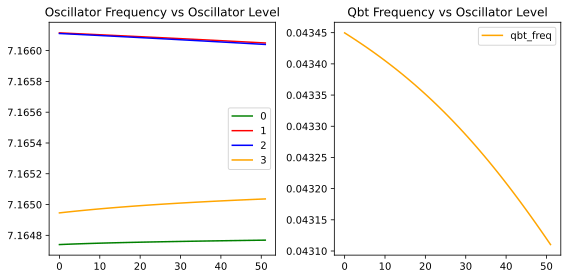

In [14]:

import sys
sys.path.append('../')
from utils_models import *

def plot_frequencies_qbt_osc(dressed_ener: Callable, ols):
    colors = ['green', 'red', 'blue', 'orange']

    # Create a figure and a set of subplots
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))  # Adjusted for better spacing

    # Second subplot for oscillator frequencies
    for ql in [0, 1, 2, 3]:
        osc_energies = []
        for ol in range(0, ols - 8):
            osc_energies.append(dressed_ener(ql, ol + 1) - dressed_ener(ql, ol))
        axs[0].plot(list(range(ols - 8)), osc_energies, label=f'{ql}', color=colors[ql])
    axs[0].set_title('Oscillator Frequency vs Oscillator Level')
    axs[0].legend()



    qbt_energies = []
    for ol in range(ols-8):
        qbt_energies.append(dressed_ener(2, ol) - dressed_ener(1, ol))
    axs[1].plot(list(range(ols-8)), qbt_energies, label=f'qbt_freq', color=colors[ql])
    axs[1].set_title('Qbt Frequency vs Oscillator Level')
    axs[1].legend()

    # Show the plots
    plt.tight_layout()  # Adjust the layout to make room for the legend
    plt.show()
    
    
max_ql = 20
max_ol = 60

system = FluxoniumOscillatorSystem(
    computaional_states = '1,2',
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    Er = 7.16518677 ,
    qubit_level = max_ql,
    osc_level = max_ol,
    g_strength = 0.18,
    products_to_keep=[[ql,ol] for ql in [0,1,2,3] for ol in range(max_ol)] 
    )


energies=  system.hilbertspace.eigenvals(system.qbt.truncated_dim * system.osc.truncated_dim )


def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]


ols = system.osc.truncated_dim

plot_frequencies_qbt_osc(dressed_ener, ols)

In [15]:
freqs = np.linspace(7.155,7.175,100)
freqs

array([7.155     , 7.15520202, 7.15540404, 7.15560606, 7.15580808,
       7.1560101 , 7.15621212, 7.15641414, 7.15661616, 7.15681818,
       7.1570202 , 7.15722222, 7.15742424, 7.15762626, 7.15782828,
       7.1580303 , 7.15823232, 7.15843434, 7.15863636, 7.15883838,
       7.1590404 , 7.15924242, 7.15944444, 7.15964646, 7.15984848,
       7.16005051, 7.16025253, 7.16045455, 7.16065657, 7.16085859,
       7.16106061, 7.16126263, 7.16146465, 7.16166667, 7.16186869,
       7.16207071, 7.16227273, 7.16247475, 7.16267677, 7.16287879,
       7.16308081, 7.16328283, 7.16348485, 7.16368687, 7.16388889,
       7.16409091, 7.16429293, 7.16449495, 7.16469697, 7.16489899,
       7.16510101, 7.16530303, 7.16550505, 7.16570707, 7.16590909,
       7.16611111, 7.16631313, 7.16651515, 7.16671717, 7.16691919,
       7.16712121, 7.16732323, 7.16752525, 7.16772727, 7.16792929,
       7.16813131, 7.16833333, 7.16853535, 7.16873737, 7.16893939,
       7.16914141, 7.16934343, 7.16954545, 7.16974747, 7.16994

In [16]:
def get_matrix_element(ql):
    a = system.hilbertspace.op_in_dressed_eigenbasis(system.osc.annihilation_operator)
    operator = a+a.dag()
    element = operator[system.product_to_dressed[(ql,1)],system.product_to_dressed[(ql,0)]]
    return np.abs(element) 
g0g1 = get_matrix_element(0)
e0e1 = get_matrix_element(1)
f0f1 = get_matrix_element(2)
h0h1 = get_matrix_element(3)
max_element = max([g0g1, e0e1, f0f1, h0h1])
g0g1, e0e1, f0f1, h0h1, max_element

(0.9892491860658857,
 0.9997192538354479,
 0.9992887153818182,
 0.9994411018788865,
 0.9997192538354479)

In [17]:
t_stop = 0.5 / 0.0015/ max_element
t_stop

333.42694166836503

In [18]:
import sys
sys.path.append('../')
from utils_models import *


max_ql = 20
max_ol = 20

t_stop = 334

tlist = np.linspace(0,t_stop,t_stop)


In [25]:

with open(f'../pickles/three_outcome_response.pkl', 'rb') as file:
    results = pickle.load(file)

In [26]:
pn_exp = [[] for _ in [0,1,2,3]]
result_counter = 0
for initial_i in [0,1,2,3]:
    for freq in freqs:
        pn_exp[initial_i].append(np.max(results[result_counter].expect[0]))
        result_counter += 1

(7.16, 7.171)

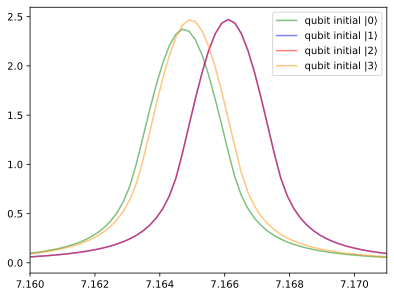

In [29]:
colors = ['green','blue','red','darkorange']
for i in [0,1,2,3]:
    plt.plot(freqs,pn_exp[i],color = colors[i],alpha = 0.5,label = rf'qubit initial $ | {i} \rangle$')
plt.legend()
plt.xlim(7.1600,7.171)